

---

## 🖼️ 1. How Are Images Stored?

An image is **not a picture** to a computer — it’s a **grid of numbers**.

Each number represents the **intensity of light** at a point called a **pixel** (picture element).

### 🔹 Grayscale Image
- Each pixel: a single number from `0` to `255`
  - `0` = black
  - `255` = white
  - Values in between = shades of gray

For example, a **28×28 grayscale image** (like MNIST digit) is stored as a **2D array**:

```python
[[  0,   0,   0, ...,   0,   0,   0],
 [  0,   0,  25, ...,   0,   0,   0],
 [  0,  50, 200, ...,  70,   0,   0],
 ...
 [  0,   0,   0, ...,   0,   0,   0]]
```

This is a **28×28 matrix** → 784 numbers.

---

### 🔹 Color Image (RGB)
Color images have **three values per pixel**:  
- **R**ed  
- **G**reen  
- **B**lue  

Each still ranges from `0` to `255`.

So a **32×32 color image** is stored as a **3D array** of shape `(32, 32, 3)`:
- First two dimensions: spatial (height × width)
- Third dimension: channels (R, G, B)

Example:
```python
image[10, 15, 0]  # Red value at row 10, column 15
image[10, 15, 1]  # Green
image[10, 15, 2]  # Blue
```

If all three are `255` → white  
If all are `0` → black  
If R=255, G=0, B=0 → pure red

---

## 📦 2. Image as a Tensor

In machine learning, images are stored as **tensors** (multi-dimensional arrays):

| Type | Shape |
|------|-------|
| Single grayscale image | `(28, 28)` or `(28, 28, 1)` |
| Single color image | `(32, 32, 3)` |
| Batch of 32 grayscale images | `(32, 28, 28, 1)` |
| Batch of 64 color images | `(64, 32, 32, 3)` |

> 🔁 The format `(batch, height, width, channels)` is called **NHWC** (used in TensorFlow)  
> PyTorch uses `(N, C, H, W)` — channels first.

---

## 🧼 3. Preprocessing: From Raw Pixels to ML Input

Raw pixel values (0–255) are not ideal for training. We **normalize** them.

### ✅ Common Normalization:
```python
image = image / 255.0  # Scale to [0, 1]
```
Now pixel values are between `0.0` and `1.0` → better for neural networks.

Sometimes:
```python
image = (image - 127.5) / 127.5  # Scale to [-1, 1]
```

> Why? Helps gradients flow better during training.

---

## 🧠 4. How Do Machine Learning Models Use Images?

### 🔹 Traditional ML (e.g., SVM, Random Forest)
- Flatten the image into a vector
- Example: `28x28` → `784`-dimensional vector
- Treat each pixel as a feature

❌ Problem: **Loses spatial structure**  
→ Can’t recognize that adjacent pixels form edges

---

### 🔹 Deep Learning (CNNs)
- Keeps the 2D structure
- Uses **convolution** to detect local patterns

#### How a CNN "Sees" an Image:
1. **Input**: `(28, 28, 1)` — raw pixel grid
2. **Conv Layer**: Applies filters that slide across the image
   - One filter detects vertical edges
   - Another detects horizontal edges
3. **Feature Map**: Output shows where each pattern appears
4. **Pooling**: Reduces size, keeps important features
5. **Final Layers**: Classify based on learned features

> ✅ CNNs **learn what to look for** — no manual feature engineering needed.

---

## 🔄 5. From Image File to Model Input (Step-by-Step)

Let’s say you have `cat.jpg`.

Here’s how it becomes input to a model:

1. **Read file** → decode JPEG into pixel array
2. **Resize** → to fixed size (e.g., 224×224)
3. **Convert to tensor** → NumPy or PyTorch/TensorFlow tensor
4. **Normalize** → divide by 255, or use mean/std
5. **Add batch dimension** → from `(224,224,3)` to `(1,224,224,3)`
6. **Feed to model**

```python
# Pseudocode
image = load_image("cat.jpg")           # Read
image = resize(image, (224, 224))       # Resize
image = image / 255.0                   # Normalize
image = np.expand_dims(image, axis=0)   # Add batch
predictions = model.predict(image)      # Run
```

---

## 🎯 6. Key Takeaways

| Fact | Explanation |
|------|-------------|
| **Images are arrays of numbers** | Each pixel = one or more numbers (0–255) |
| **Grayscale: 1 channel** | Shape `(H, W)` or `(H, W, 1)` |
| **Color: 3 channels (RGB)** | Shape `(H, W, 3)` |
| **Batch of images** | Shape `(N, H, W, C)` |
| **Normalization is essential** | Scale pixels to [0,1] or [-1,1] |
| **CNNs preserve spatial info** | ANNs flatten and lose it |
| **Pixels are features** | But raw pixels aren’t enough — models must learn patterns |

---

## 🧪 Example: MNIST Digit (7)

Raw 28×28 image (small part shown):

```
  0   0   0   0   0
  0   0 255 255   0
  0   0   0 255   0
  0   0   0 255   0
  0   0   0   0   0
```

→ A human sees a "7"  
→ A CNN learns to see the **top horizontal bar** and **diagonal stroke**  
→ An ANN sees 784 numbers with no spatial meaning

---

## ✅ Summary

- Images are stored as **numerical grids**
- Each pixel is a number (0–255) representing brightness
- Color images have **three values per pixel** (RGB)
- In ML, images are **normalized** and fed as **tensors**
- **CNNs use spatial structure** to learn features like edges, shapes, objects
- **ANNs flatten images** and lose spatial relationships

> So when you feed an image to a model, you're not giving it a "picture" —  
> you're giving it a **structured array of numbers** that the model learns to interpret.

This is how machines "see".

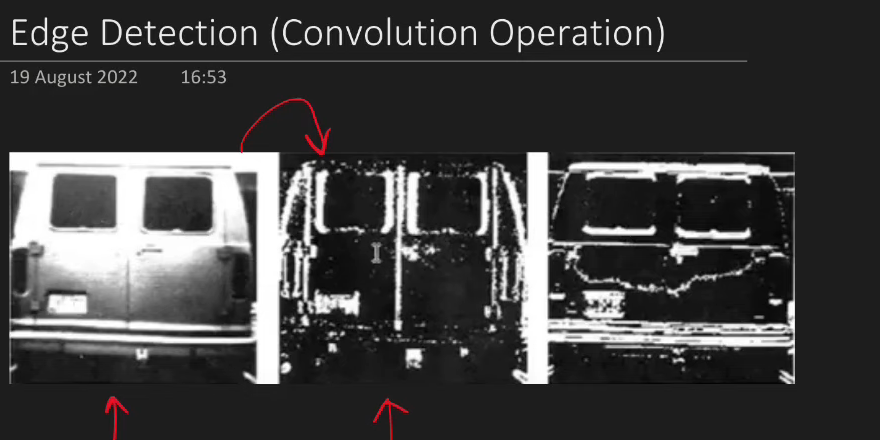

#What is Edge for him?
an **edge** in Convolutional Neural Networks (CNNs) is:

- **Definition**: A significant change in pixel intensity or color in an image.
- **Detection**: CNNs use filters (like Sobel) to identify edges during the convolution process.
- **Types**: Horizontal, vertical, and diagonal edges.
- **Importance**: Edges help CNNs recognize shapes and objects, essential for tasks like image classification and object detection.

##How filter works

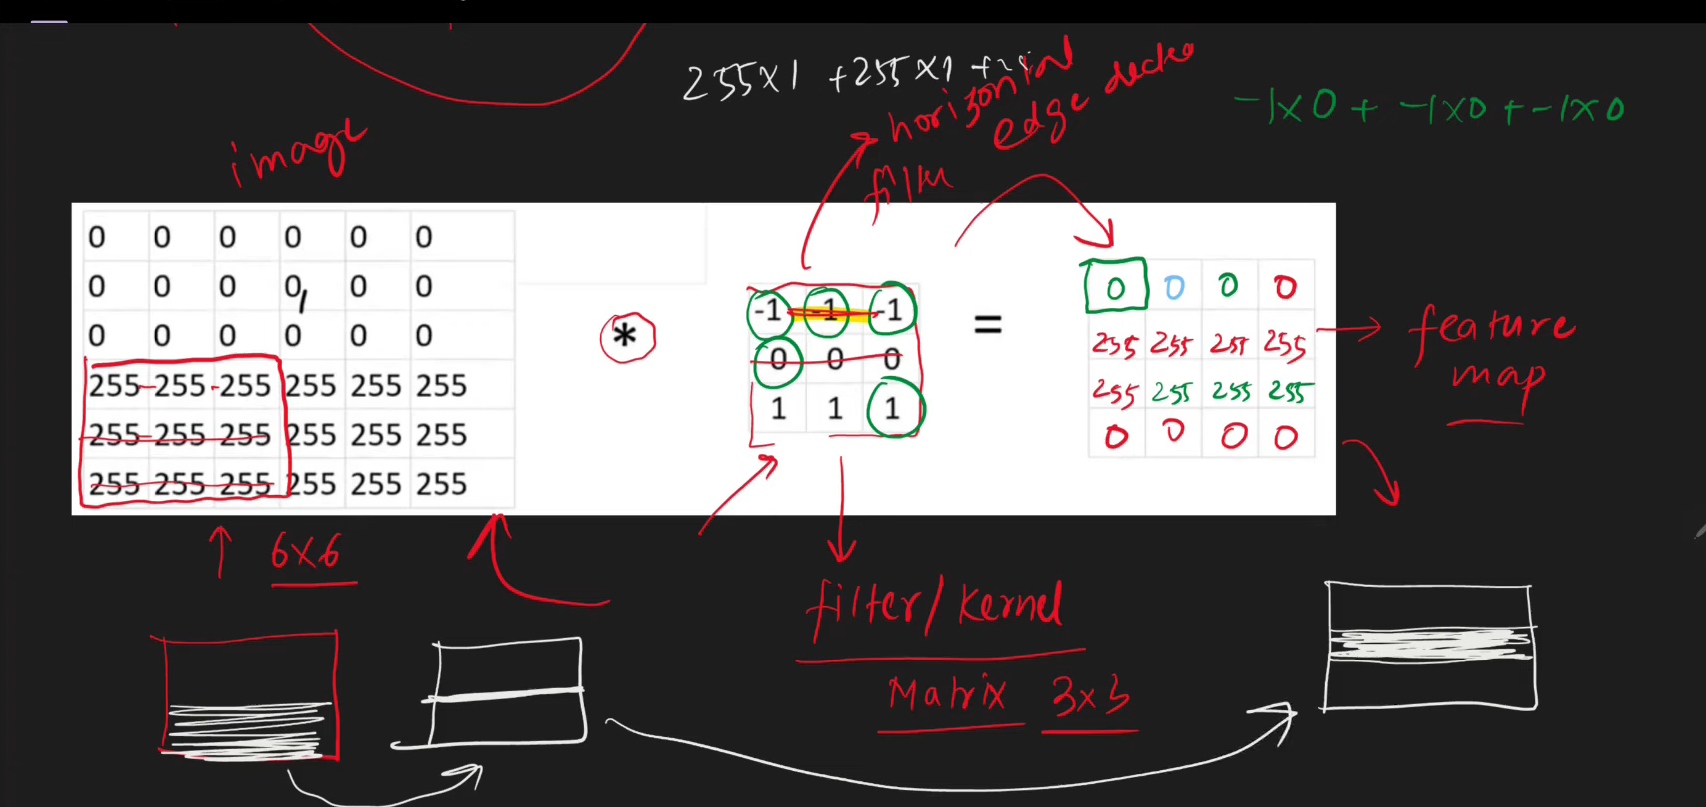

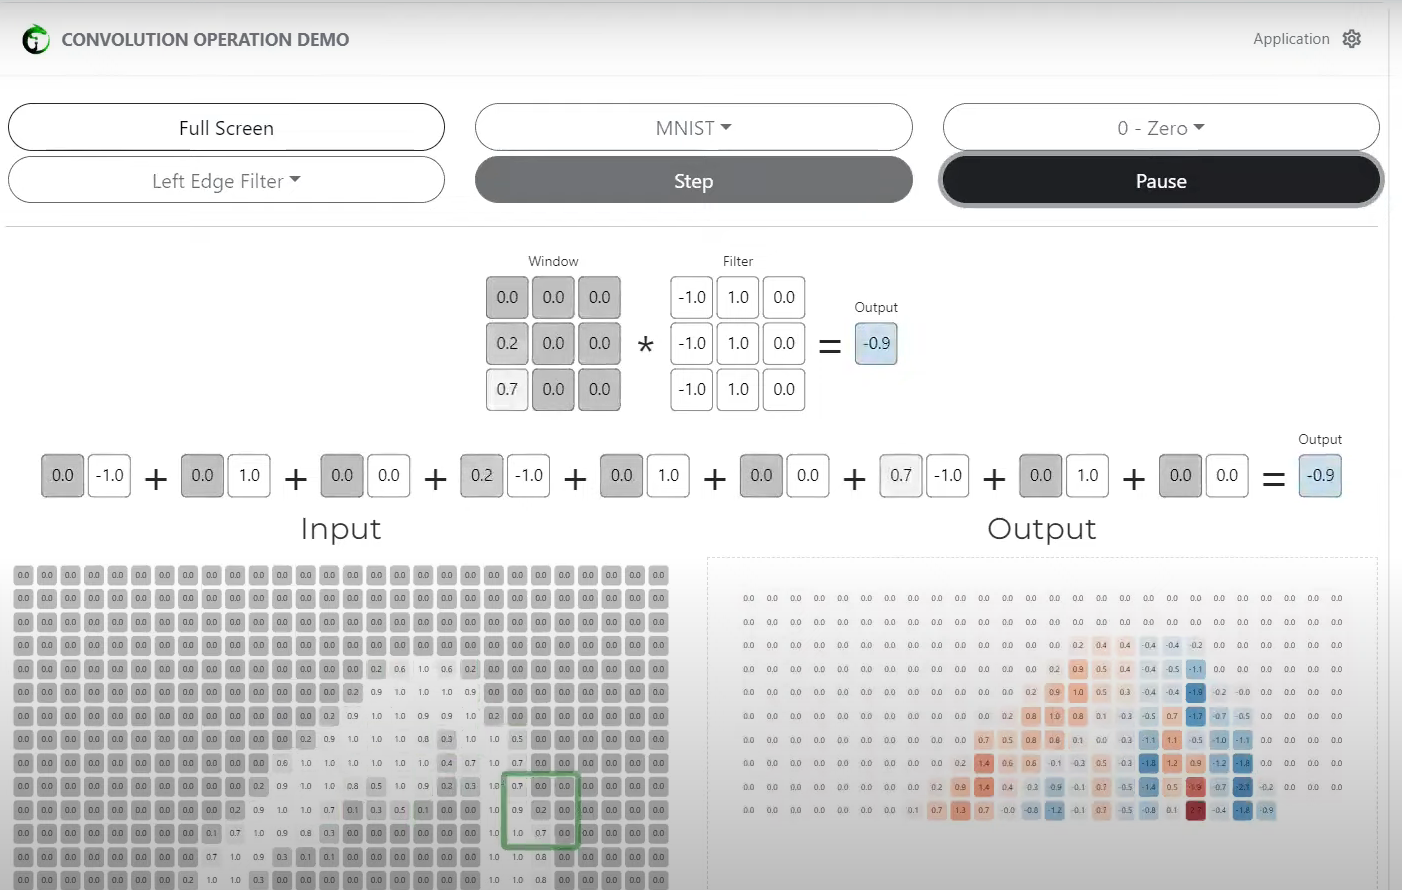

###Output ,how matrix work and how output expected here

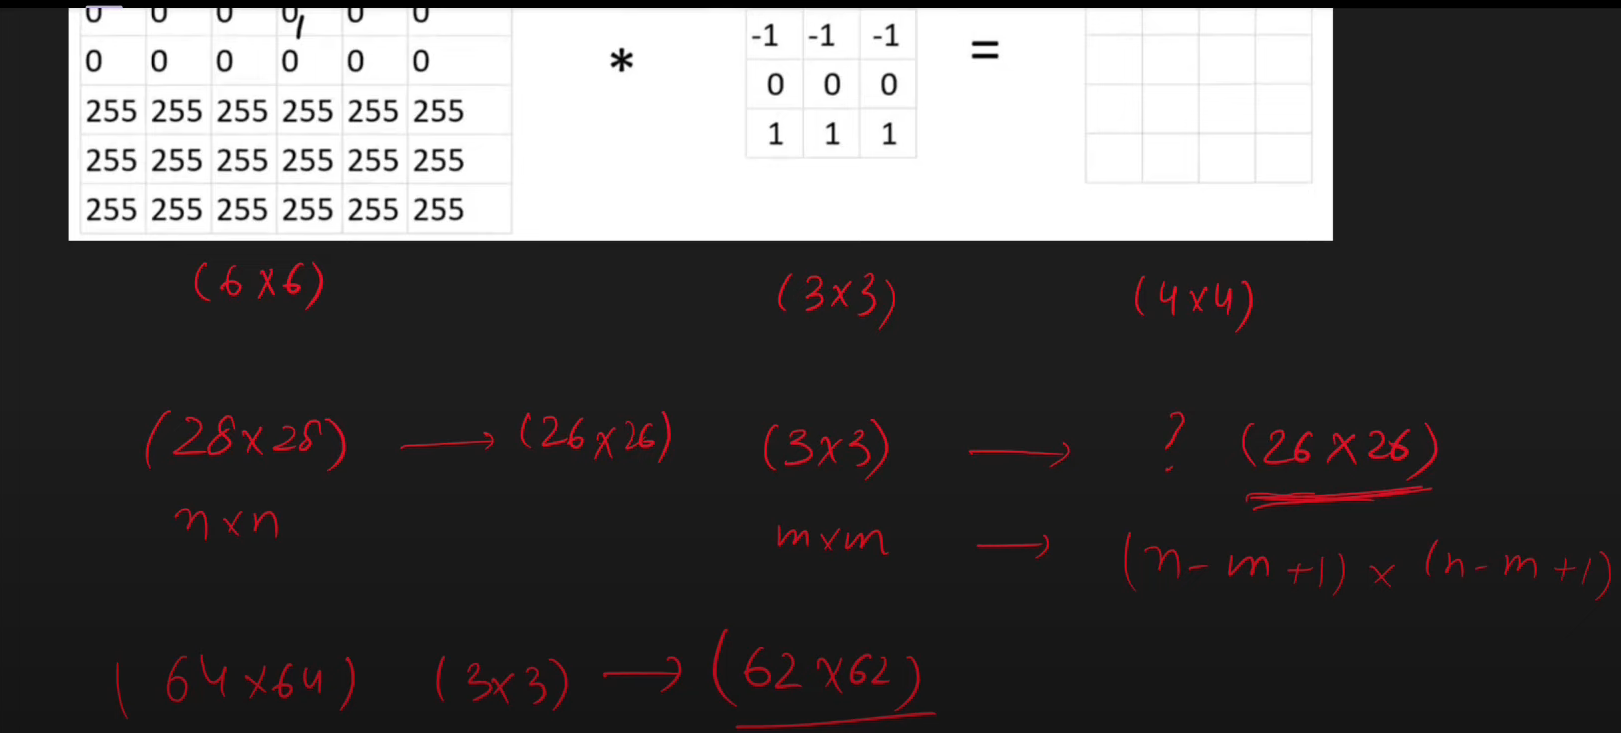

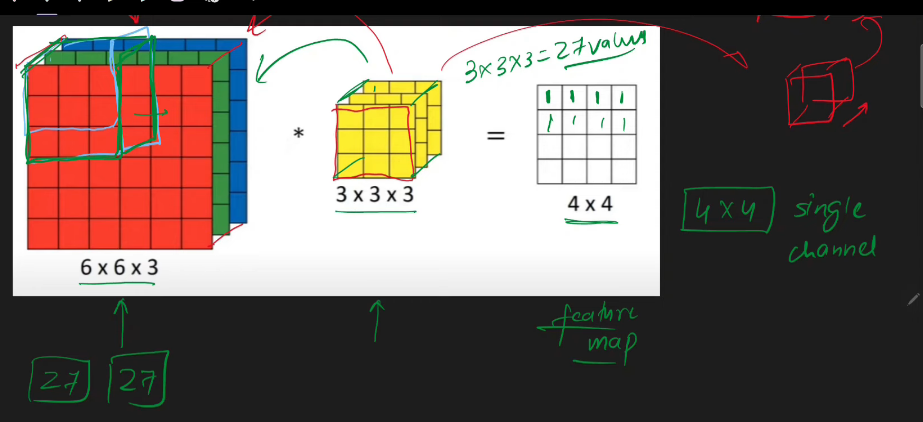

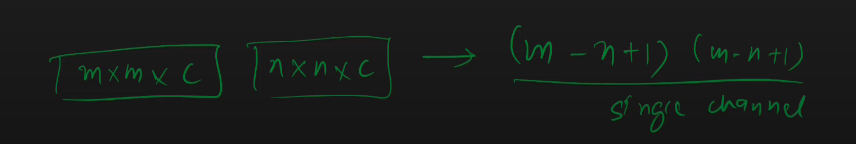

##Multiple Filter working

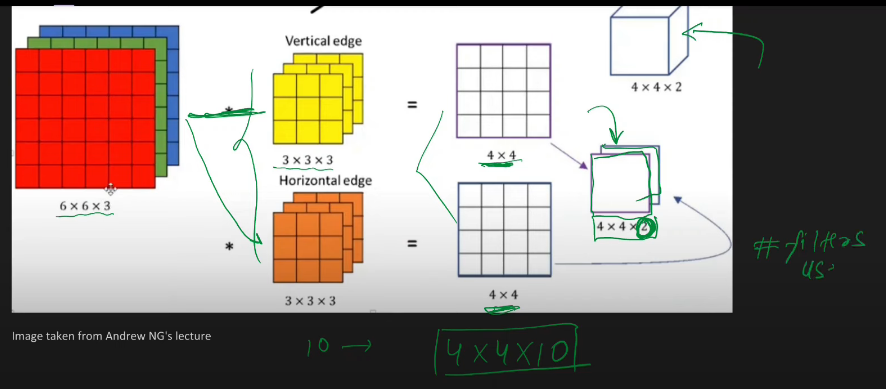



---

## 🎯 What is Convolution in a CNN?

**Convolution** is the core operation in a **Convolutional Neural Network (CNN)**.  
It’s how the network **"sees"** — by detecting patterns like **edges, corners, and textures** in an image.

Think of it like a **flashlight sliding over a photo**, looking for specific features.

---

## 🖼️ Visual Intuition (Picture in Words)

Imagine you have a small **3×3 filter (or kernel)** — like a magnifying glass.

You slide this filter over the image, **step by step**, from left to right, top to bottom.

At each position:
- You **multiply** the filter values with the image pixels underneath
- You **add up** all the results
- That sum becomes **one pixel** in a new image called a **feature map**

This process is **convolution**.

---

### 🔍 Example: Detecting a Vertical Edge

Suppose your image looks like this (simplified 6×6 grayscale):

```
Image (6×6):
  0   0   0   255 255 255
  0   0   0   255 255 255
  0   0   0   255 255 255
  0   0   0   255 255 255
  0   0   0   255 255 255
  0   0   0   255 255 255
```

This is a **vertical edge** — left side dark (0), right side bright (255).

Now apply this **3×3 filter**:

```
Filter (detects vertical edges):
 +1   0  -1
 +1   0  -1
 +1   0  -1
```

This filter is designed to **highlight vertical changes**:
- +1 on left → boosts dark values
- -1 on right → reduces bright values
- 0 in middle

---

### 🧮 Step-by-Step Math

Let’s slide the filter to the top-left position:

**Image patch under filter (3×3):**
```
  0   0   0
  0   0   0
  0   0   0
```

**Element-wise multiplication:**
```
(0×+1) + (0×0) + (0×-1) = 0
(0×+1) + (0×0) + (0×-1) = 0
(0×+1) + (0×0) + (0×-1) = 0
```

**Sum = 0**

So the first pixel in the **feature map** is `0`.

Now move the filter one step to the right:

**Image patch:**
```
  0   0   0
  0   0   0
  0   0   0
```

Still all zeros → sum = 0

Keep moving… until the filter straddles the edge:

**Image patch:**
```
  0   0 255
  0   0 255
  0   0 255
```

Now multiply:
```
(0×+1) + (0×0) + (255×-1) = -255
(0×+1) + (0×0) + (255×-1) = -255
(0×+1) + (0×0) + (255×-1) = -255
```

**Sum = -255 + -255 + -255 = -765**

But we usually take absolute value or use ReLU later → this becomes a **large positive response**.

This means: **"I found a strong vertical edge here!"**

As you keep sliding, the filter will give:
- **High values** where there’s a sharp left-to-right change
- **Zero** where the image is flat

The result is a **feature map** that highlights vertical edges.

---

## 📐 Mathematical Definition

Let:
- \( I \) = Input image
- \( K \) = Filter (kernel)
- \( (i,j) \) = Position in output

Then the convolution at position \( (i,j) \) is:

\[
(F * K)[i,j] = \sum_{m=0}^{2} \sum_{n=0}^{2} I[i+m, j+n] \cdot K[m,n]
\]

This is just the **sum of element-wise products**.

> 🔁 The filter slides across the image, repeating this calculation.

---

## 🔁 Key Parameters

| Term | Meaning |
|------|--------|
| **Stride** | How many pixels the filter moves each step (usually 1 or 2) |
| **Padding** | Extra zeros added around the image to control output size |
| **Output Size** | If input is \( H×W \), filter \( F×F \), stride \( S \):  
\[
\text{Output size} = \frac{H - F}{S} + 1
\] |

Example: 6×6 image, 3×3 filter, stride 1 → output is 4×4

---

## 🎨 What Do Different Filters Detect?

| Filter | Detects |
|-------|--------|
| `[[+1,0,-1],[+1,0,-1],[+1,0,-1]]` | Vertical edges |
| `[[+1,+1,+1],[0,0,0],[-1,-1,-1]]` | Horizontal edges |
| `[[0,1,0],[1,-4,1],[0,1,0]]` | Edges (Laplacian) |
| `[[1,1,1],[1,1,1],[1,1,1]]/9` | Blurring (averaging) |

The CNN **learns the best filters** during training — it doesn’t use fixed ones like above.

---

## 🧠 Why Is This Useful?

- **Local Feature Detection**: Each filter looks for a small pattern
- **Weight Sharing**: The same filter is used everywhere → efficient
- **Translation Equivariance**: If the object moves, the feature moves too (helps recognition)
- **Hierarchical Learning**: Early layers detect edges, deeper layers combine them into shapes

---

## ✅ Summary

| Concept | Explanation |
|--------|-------------|
| **Convolution** | A filter slides over the image, computing dot products |
| **Filter (Kernel)** | Small matrix that detects patterns (e.g., edges) |
| **Feature Map** | Output showing where the pattern was found |
| **Math** | Sum of element-wise multiplication |
| **Stride** | Step size of the filter |
| **Purpose** | Extract meaningful features from images automatically |

---

## 🖼️ Final Picture (in Words)

```
Input Image       Filter           Feature Map
┌─────┬─────┐     ┌─────┐          ┌─────┐
│ 0 0 │ 255 │     │+1 0 │          │     │
│ 0 0 │ 255 │  *  │+1 0 │  →  │ 0   │ 765 │
│     │     │     │+1 0 │          │     │
└─────┴─────┘     └─────┘          └─────┘
       ← Slide →                       ↑
   "Edge detected here!"
```

> This is how a CNN starts to "see".

Now you know: **Convolution is just a sliding window that multiplies and adds — to find patterns in images.**

And the network learns which patterns matter.